In [ ]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

In [3]:

import pandas as pd
import pandas_gbq
from google.oauth2 import service_account

from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = 'google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'coral-bucksaw-482803-p2'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [4]:

# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [ 
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    IsRootEvent,
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401
  AND IsRootEvent = 1
  AND ActionGeo_Type IN (3, 4, 5)
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})

"""
df = pandas_gbq.read_gbq(
    query,
    project_id=project_id,
    credentials=credentials,
    progress_bar_type='tqdm'   # 진행률 표시
)

print(f"총 {len(df):,}건 수집 완료")
display(df.head())


Downloading: 100%|██████████|
총 11,897건 수집 완료


,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160911,1,190,-10.0,8,-14.525140,4,25.0478,121.532,http://www.wcyb.com/news/taiwan-tour-bus-drive...
1,20170101,1,150,-7.2,10,-2.144772,4,25.0478,121.532,http://www.globalsecurity.org/wmd/library/news...
2,20160708,1,154,-7.2,3,-5.988024,4,25.0478,121.532,http://www.wnd.com/2016/07/terrifying-category...
3,20160522,1,150,-7.2,5,-0.806452,4,39.9289,116.388,http://bilbaoya.com/2016/05/23/taiwan-swears-i...
4,20160522,1,150,-7.2,5,0.634249,4,25.0327,121.275,http://fait-religieux.com/2016/05/22/taiwan-sw...


In [5]:
import pandas as pd

# 기본 파악
print("shape:", df.shape)
print("\n결측값 비율(%)")
print((df.isnull().mean() * 100).round(2))

# 날짜 변환
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
print("\n날짜 범위:", df['SQLDATE'].min(), "~", df['SQLDATE'].max())

# 연도별 분포
df['year'] = df['SQLDATE'].dt.year
print("\n연도별 이벤트 수")
print(df['year'].value_counts().sort_index())

shape: (11897, 10)

결측값 비율(%)
SQLDATE           0.0
IsRootEvent       0.0
EventCode         0.0
GoldsteinScale    0.0
NumMentions       0.0
AvgTone           0.0
ActionGeo_Type    0.0
ActionGeo_Lat     0.0
ActionGeo_Long    0.0
SOURCEURL         0.0
dtype: float64

날짜 범위: 2013-04-01 00:00:00 ~ 2026-05-04 00:00:00

연도별 이벤트 수
year
2013      68
2014     375
2015     481
2016     509
2017     435
2018     705
2019     540
2020    1055
2021    1279
2022    2126
2023    1758
2024    1314
2025    1040
2026     212
Name: count, dtype: int64


In [6]:
# 전체 연도 다 보기
print(df['year'].value_counts().sort_index().to_string())

year
2013      68
2014     375
2015     481
2016     509
2017     435
2018     705
2019     540
2020    1055
2021    1279
2022    2126
2023    1758
2024    1314
2025    1040
2026     212


In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지

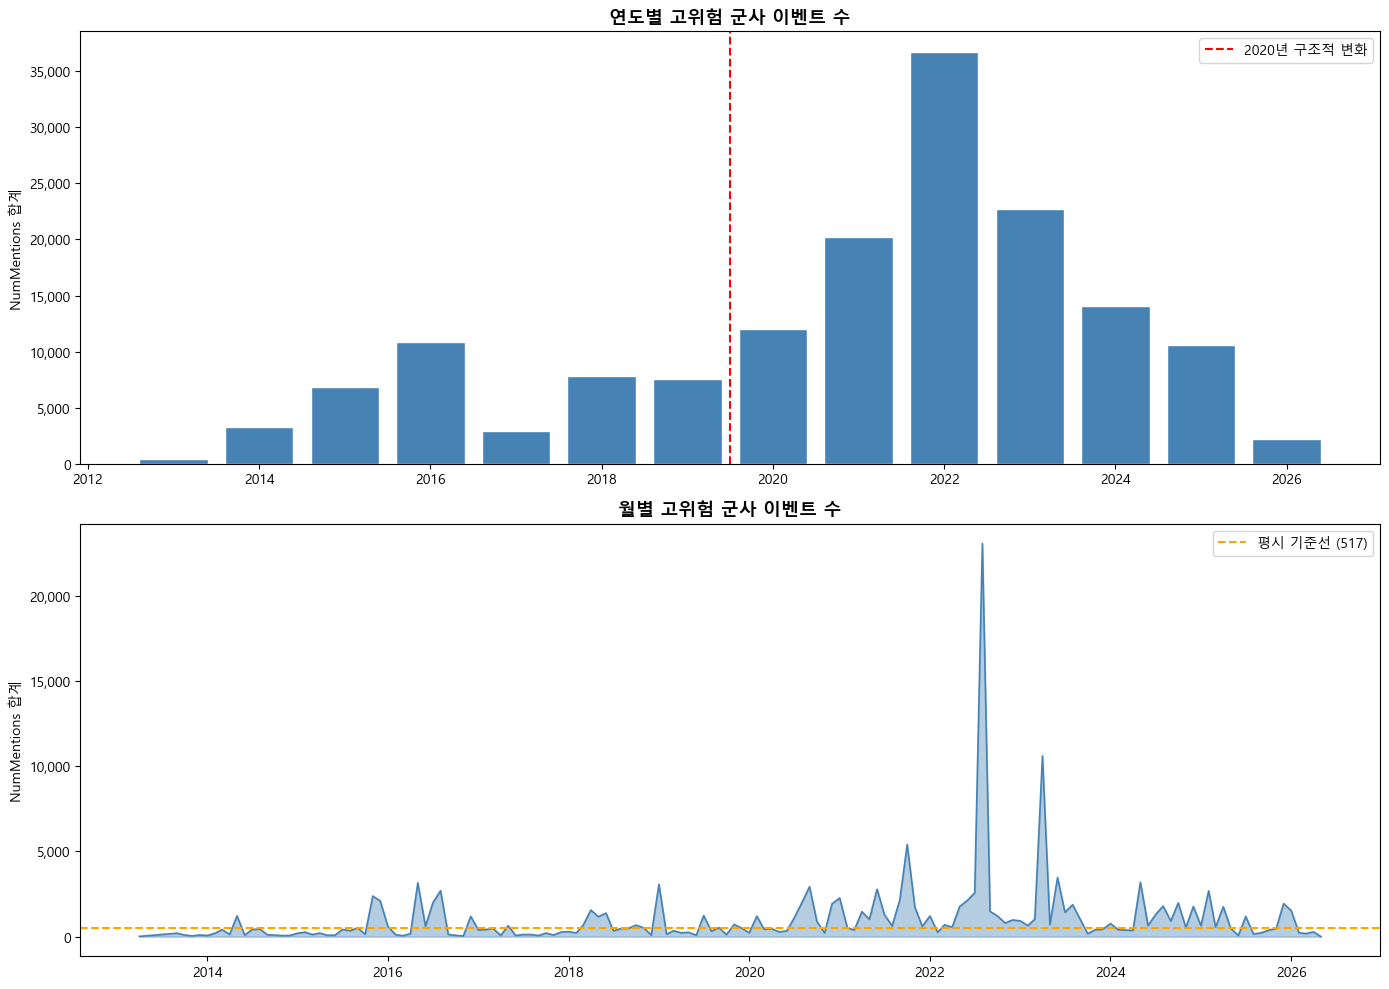

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 연도별 막대그래프
yearly = df.groupby('year')['NumMentions'].sum()
axes[0].bar(yearly.index, yearly.values, color='steelblue', edgecolor='white')
axes[0].set_title('연도별 고위험 군사 이벤트 수', fontsize=13, fontweight='bold')
axes[0].set_ylabel('NumMentions 합계')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2020년 변곡점 표시
axes[0].axvline(2019.5, color='red', linestyle='--', linewidth=1.5,
                label='2020년 구조적 변화')
axes[0].legend()

# 월별 추이
monthly = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    event_count=('NumMentions', 'sum'),
    avg_tone=('AvgTone', 'mean'),
    avg_goldstein=('GoldsteinScale', 'mean')
).reset_index()
monthly['SQLDATE'] = monthly['SQLDATE'].dt.to_timestamp()

axes[1].fill_between(monthly['SQLDATE'], monthly['event_count'],
                     alpha=0.4, color='steelblue')
axes[1].plot(monthly['SQLDATE'], monthly['event_count'],
             color='steelblue', linewidth=1.2)
axes[1].set_title('월별 고위험 군사 이벤트 수', fontsize=13, fontweight='bold')
axes[1].set_ylabel('NumMentions 합계')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 평시 베이스라인
baseline = monthly[monthly['SQLDATE'].dt.year <= 2019]['event_count'].mean()
axes[1].axhline(baseline, color='orange', linestyle='--',
                linewidth=1.5, label=f'평시 기준선 ({baseline:,.0f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('yearly_monthly_military.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# 시기별 기준선 분리
baseline_평시 = monthly[monthly['SQLDATE'].dt.year <= 2019]['event_count'].mean()
baseline_고긴장 = monthly[monthly['SQLDATE'].dt.year >= 2020]['event_count'].mean()

print(f"평시 기준선    (2013~2019): {baseline_평시:,.0f}")
print(f"고긴장 기준선  (2020~현재): {baseline_고긴장:,.0f}")

평시 기준선    (2013~2019): 517
고긴장 기준선  (2020~현재): 1,538


In [14]:
import matplotlib.pyplot as plt
import scipy.stats as sp_stats
import numpy as np
import seaborn as sns

# ── 데이터 준비 ──────────────────────────────────
# 월별 집계
monthly = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    event_count=('NumMentions', 'sum'),
    avg_tone=('AvgTone', 'mean'),
    avg_goldstein=('GoldsteinScale', 'mean')
).reset_index()
monthly['SQLDATE'] = monthly['SQLDATE'].dt.to_timestamp()
monthly['tone_delta'] = monthly['avg_tone'].diff()  # Tone 변화량

# ── 상관계수 출력 ─────────────────────────────────
pairs = [
    ('event_count', 'avg_tone',      '기사량 vs Tone'),
    ('event_count', 'avg_goldstein', '기사량 vs Goldstein'),
    ('avg_tone',    'avg_goldstein', 'Tone vs Goldstein'),
    ('event_count', 'tone_delta',    '기사량 vs Tone변화량'),
]

print("=" * 55)
print(f"{'조합':<25} {'상관계수':>8}  {'p-value':>10}  {'해석'}")
print("=" * 55)
for x_col, y_col, label in pairs:
    data = monthly[[x_col, y_col]].dropna()
    corr, p = sp_stats.pearsonr(data[x_col], data[y_col])
    
    # 해석
    if abs(corr) >= 0.6:
        interpret = "강한 상관 ⚠️"
    elif abs(corr) >= 0.3:
        interpret = "중간 상관"
    else:
        interpret = "약한 상관 ✅"
    
    sig = "유의" if p < 0.05 else "비유의"
    print(f"{label:<25} {corr:>8.3f}  {p:>10.4f}  {interpret} ({sig})")
print("=" * 55)

조합                            상관계수     p-value  해석
기사량 vs Tone                 -0.165      0.0410  약한 상관 ✅ (유의)
기사량 vs Goldstein             0.178      0.0274  약한 상관 ✅ (유의)
Tone vs Goldstein           -0.428      0.0000  중간 상관 (유의)
기사량 vs Tone변화량               0.005      0.9475  약한 상관 ✅ (비유의)


c:\Users\user\.conda\envs\sia_wevengers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\user\AppData\Local\Temp\ipykernel_513844\1772894448.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
c:\Users\user\.conda\envs\sia_wevengers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


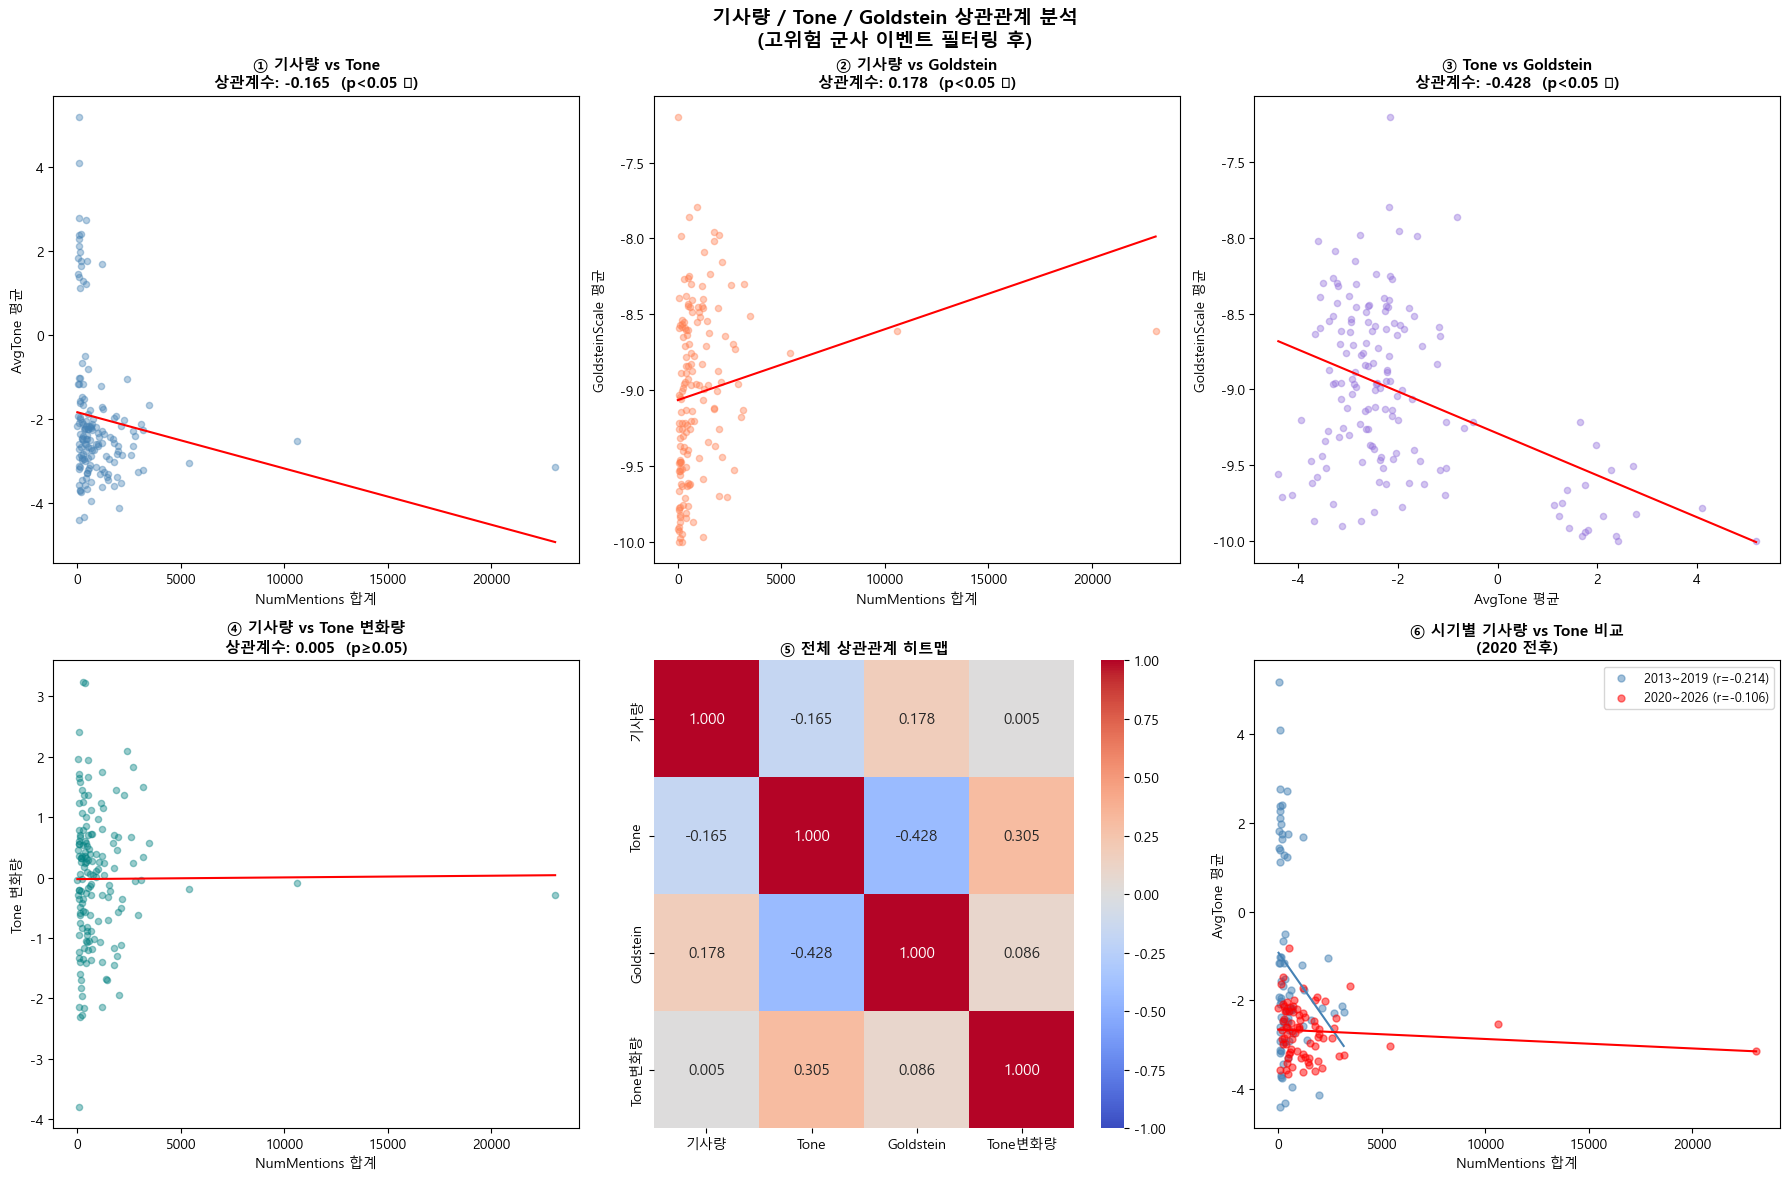

In [15]:
# ── 시각화 ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('기사량 / Tone / Goldstein 상관관계 분석\n(고위험 군사 이벤트 필터링 후)',
             fontsize=14, fontweight='bold')

plot_pairs = [
    # (x컬럼, y컬럼, x축 라벨, y축 라벨, 제목, 색상)
    ('event_count', 'avg_tone',
     'NumMentions 합계', 'AvgTone 평균',
     '① 기사량 vs Tone', 'steelblue'),

    ('event_count', 'avg_goldstein',
     'NumMentions 합계', 'GoldsteinScale 평균',
     '② 기사량 vs Goldstein', 'coral'),

    ('avg_tone', 'avg_goldstein',
     'AvgTone 평균', 'GoldsteinScale 평균',
     '③ Tone vs Goldstein', 'mediumpurple'),

    ('event_count', 'tone_delta',
     'NumMentions 합계', 'Tone 변화량',
     '④ 기사량 vs Tone 변화량', 'teal'),
]

for idx, (x_col, y_col, xlabel, ylabel, title, color) in enumerate(plot_pairs):
    row, col = divmod(idx, 3)
    ax = axes[row, col]

    data = monthly[[x_col, y_col]].dropna()
    corr, p = sp_stats.pearsonr(data[x_col], data[y_col])

    # 산점도
    ax.scatter(data[x_col], data[y_col],
               alpha=0.4, s=20, color=color)

    # 회귀선
    slope, intercept, *_ = sp_stats.linregress(data[x_col], data[y_col])
    x_line = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color='red', linewidth=1.5)

    # 상관계수 표시
    sig_mark = "p<0.05 ✅" if p < 0.05 else "p≥0.05"
    ax.set_title(f'{title}\n상관계수: {corr:.3f}  ({sig_mark})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# ── 히트맵 (전체 상관관계 한눈에) ────────────────
ax = axes[1, 1]
corr_matrix = monthly[['event_count', 'avg_tone',
                        'avg_goldstein', 'tone_delta']].corr()
corr_matrix.index = ['기사량', 'Tone', 'Goldstein', 'Tone변화량']
corr_matrix.columns = ['기사량', 'Tone', 'Goldstein', 'Tone변화량']

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 11})
ax.set_title('⑤ 전체 상관관계 히트맵', fontsize=11, fontweight='bold')

# ── 시기별 상관관계 비교 (2020 전후) ─────────────
ax = axes[1, 2]
before = monthly[monthly['SQLDATE'].dt.year < 2020][['event_count', 'avg_tone']].dropna()
after  = monthly[monthly['SQLDATE'].dt.year >= 2020][['event_count', 'avg_tone']].dropna()

corr_before, _ = sp_stats.pearsonr(before['event_count'], before['avg_tone'])
corr_after,  _ = sp_stats.pearsonr(after['event_count'],  after['avg_tone'])

ax.scatter(before['event_count'], before['avg_tone'],
           alpha=0.5, s=25, color='steelblue', label=f'2013~2019 (r={corr_before:.3f})')
ax.scatter(after['event_count'],  after['avg_tone'],
           alpha=0.5, s=25, color='red',       label=f'2020~2026 (r={corr_after:.3f})')

# 각 시기별 회귀선
for data, color in [(before, 'steelblue'), (after, 'red')]:
    slope, intercept, *_ = sp_stats.linregress(data['event_count'], data['avg_tone'])
    x_line = np.linspace(data['event_count'].min(), data['event_count'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=1.5)

ax.set_title('⑥ 시기별 기사량 vs Tone 비교\n(2020 전후)', fontsize=11, fontweight='bold')
ax.set_xlabel('NumMentions 합계')
ax.set_ylabel('AvgTone 평균')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
spike_months = monthly.nlargest(10, 'event_count')[
    ['SQLDATE', 'event_count', 'avg_tone', 'avg_goldstein']
]
print(spike_months.to_string())

       SQLDATE  event_count  avg_tone  avg_goldstein
108 2022-08-01        23078 -3.142868      -8.612011
116 2023-04-01        10605 -2.522508      -8.611544
98  2021-10-01         5406 -3.036479      -8.756319
118 2023-06-01         3470 -1.677170      -8.512903
129 2024-05-01         3190 -3.218391      -8.297585
33  2016-05-01         3160 -2.250831      -9.128889
65  2019-01-01         3065 -2.123305      -9.176471
85  2020-09-01         2927 -3.248840      -8.956710
94  2021-06-01         2780 -2.396139      -8.727619
36  2016-08-01         2696 -2.292392      -9.522034


In [17]:
!pip install geopy


   ---------------------------------------- 0/2 [geographiclib]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]



In [18]:

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd
import time

# ── 샘플 추출 (전체 하면 너무 오래 걸림) ──────────
# 스파이크 상위 3개월 + 랜덤 샘플
spike_dates = ['2022-08', '2023-04', '2021-10']
spike_sample = df[
    df['SQLDATE'].dt.to_period('M').astype(str).isin(spike_dates)
].sample(min(50, len(df)), random_state=42)

random_sample = df.sample(50, random_state=42)
sample = pd.concat([spike_sample, random_sample]).drop_duplicates()

print(f"검증할 샘플 수: {len(sample)}개")

검증할 샘플 수: 100개


In [19]:
# ── 역지오코딩 함수 ───────────────────────────────
geolocator = Nominatim(user_agent="gdelt_verify")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_country(lat, lon):
    try:
        location = reverse(f"{lat}, {lon}", language='en')
        if location and location.raw.get('address'):
            addr = location.raw['address']
            return addr.get('country', 'Unknown')
        return 'Unknown'
    except:
        return 'Error'

# 역지오코딩 실행 (시간 걸릴 수 있어요)
sample = sample.copy()
sample['reverse_country'] = sample.apply(
    lambda row: get_country(row['ActionGeo_Lat'], row['ActionGeo_Long']),
    axis=1
)
print("역지오코딩 완료!")


역지오코딩 완료!


In [20]:
# ── 검증 결과 분석 ────────────────────────────────
print("\n=== 역지오코딩 국가 분포 ===")
print(sample['reverse_country'].value_counts())

# 대만/중국 관련 좌표 비율
target_countries = ['Taiwan', 'China']
valid_ratio = sample['reverse_country'].isin(target_countries).mean()
print(f"\n대만/중국 내 좌표 비율: {valid_ratio*100:.1f}%")
print(f"엉뚱한 좌표 비율:       {(1-valid_ratio)*100:.1f}%")


=== 역지오코딩 국가 분포 ===
reverse_country
China             48
Taiwan            34
Unknown            7
United States      5
Philippines        2
Japan              1
South Korea        1
United Kingdom     1
Australia          1
Name: count, dtype: int64

대만/중국 내 좌표 비율: 82.0%
엉뚱한 좌표 비율:       18.0%


In [21]:
# ── 좌표 범위로 1차 검증 (빠른 방법) ──────────────
# 역지오코딩 전에 bbox로 먼저 걸러내기

# 대만 해협 중심 bbox
TWN_LAT = (21.5, 25.5)   # 대만 위도
TWN_LON = (119.0, 122.5)  # 대만 경도
STRAIT_LAT = (24.0, 27.0) # 해협 위도
STRAIT_LON = (119.0, 122.0) # 해협 경도
CHN_COAST_LAT = (24.0, 30.0) # 중국 해안 위도
CHN_COAST_LON = (118.0, 122.0) # 중국 해안 경도

def classify_location(lat, lon):
    if TWN_LAT[0] <= lat <= TWN_LAT[1] and TWN_LON[0] <= lon <= TWN_LON[1]:
        return '대만 본토'
    elif STRAIT_LAT[0] <= lat <= STRAIT_LAT[1] and STRAIT_LON[0] <= lon <= STRAIT_LON[1]:
        return '대만 해협'
    elif CHN_COAST_LAT[0] <= lat <= CHN_COAST_LAT[1] and CHN_COAST_LON[0] <= lon <= CHN_COAST_LON[1]:
        return '중국 해안'
    elif 20 <= lat <= 30 and 115 <= lon <= 125:
        return '주변 해역'
    else:
        return '범위 외'

df['location_class'] = df.apply(
    lambda row: classify_location(row['ActionGeo_Lat'], row['ActionGeo_Long']),
    axis=1
)

print("\n=== 좌표 지역 분류 결과 ===")
print(df['location_class'].value_counts())
print(f"\n위성 촬영 가능 지역 비율: "
      f"{(df['location_class'] != '범위 외').mean()*100:.1f}%")


=== 좌표 지역 분류 결과 ===
location_class
범위 외     6438
대만 본토    4579
중국 해안     502
주변 해역     355
대만 해협      23
Name: count, dtype: int64

위성 촬영 가능 지역 비율: 45.9%
